# Convolutional Neural Networks – Hands‑on Exercises
***Goals**
1. CNN for MNIST classification
2. Visualizing feature maps in a CNN
3. Building a small ResNet with residual connections

## Setup

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


---
# Question 1 — CNN for MNIST
Build a CNN to classify handwritten digits.


In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values to [0, 1]

x_train = x_train[..., None]
x_test = x_test[..., None]

print(x_train.shape)


(60000, 28, 28, 1)


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

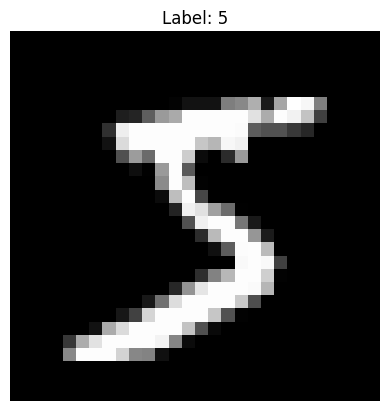

In [3]:
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.axis("off")


### Build the CNN

# 1.

Build an train a CNN model with the following architecture:

- Conv2D with 32 filters, kernel size 3x3, activation 'relu'
- MaxPooling2D with pool size 2x2
- Conv2D with 64 filters, kernel size 3x3, activation 'relu'
- MaxPooling2D with pool size 2x2
- Flatten
- Dense with 128 units, activation 'relu'
- Dense with 10 units, activation 'softmax'

---
# Exercise 2 — Visualizing CNN Feature Maps
We inspect intermediate activations to understand what the CNN learns.

In [8]:
sample_image = x_test[0:1]

# Ensure the model is called so input tensors are available
_ = model(sample_image)

layer_outputs = [layer.output for layer in model.layers if 'conv' in layer.name]
activation_model = tf.keras.Model(inputs=model.inputs, outputs=layer_outputs)

activations = activation_model.predict(sample_image)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


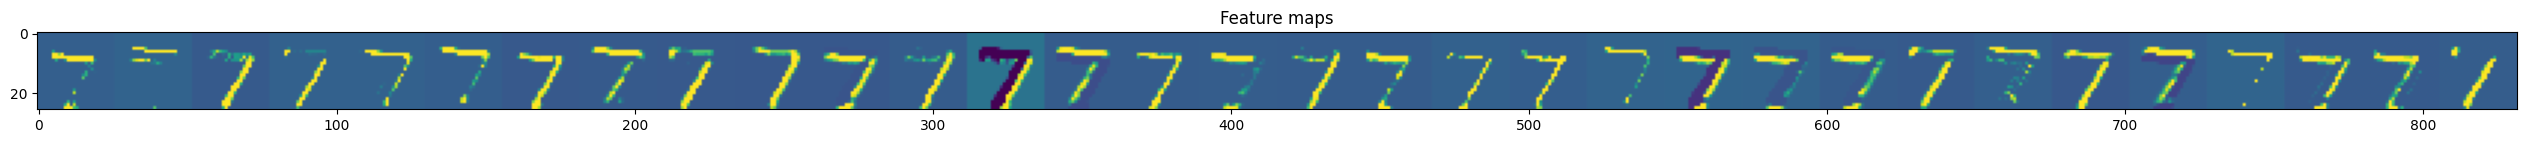

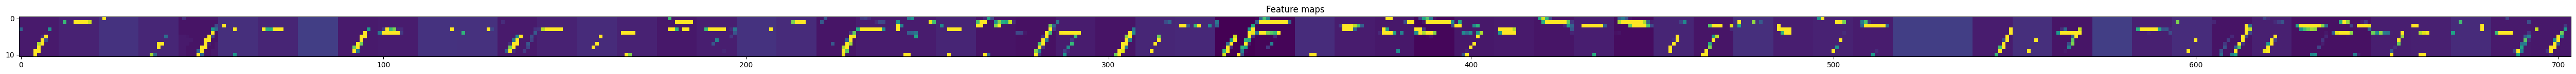

In [9]:
for layer_activation in activations:
    n_features = layer_activation.shape[-1]
    size = layer_activation.shape[1]

    display_grid = np.zeros((size, size * n_features))

    for i in range(n_features):
        channel_image = layer_activation[0, :, :, i]
        channel_image -= channel_image.mean()
        channel_image /= (channel_image.std() + 1e-5)
        channel_image *= 64
        channel_image += 128
        channel_image = np.clip(channel_image, 0, 255).astype('uint8')
        display_grid[:, i * size : (i + 1) * size] = channel_image

    scale = 1. / size
    plt.figure(figsize=(scale * display_grid.shape[1], scale * display_grid.shape[0]))
    plt.title("Feature maps")
    plt.grid(False)
    plt.imshow(display_grid, aspect='auto', cmap='viridis')


---
# Exercise 3 — Build a Small ResNet
We implement a residual block and build a small CNN using skip connections.

**Concept**:
y = F(x) + x


In [10]:
from tensorflow.keras import layers

def residual_block(x, filters):
    shortcut = x

    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(filters, 3, padding='same')(x)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)

    return x


In [11]:
inputs = tf.keras.Input(shape=(28,28,1))

x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)

x = residual_block(x, 32)
x = layers.MaxPooling2D()(x)

x = residual_block(x, 32)

x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(10, activation='softmax')(x)

resnet_model = tf.keras.Model(inputs, outputs)

resnet_model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 28, 28,    │        320 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 28, 28,    │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 28, 28,    │      9,248 │ conv2d_3[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 28, 28,    │          0 │ conv2d_4[0][0],   │
│                     │ 32)               │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 28, 28,    │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 14, 14,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 14, 14,    │      9,248 │ max_pooling2d_2[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 14, 14,    │      9,248 │ conv2d_5[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 14, 14,    │          0 │ conv2d_6[0][0],   │
│                     │ 32)               │            │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 14, 14,    │          0 │ add_1[0][0]       │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ activation_1[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 10)        │        330 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 37,642 (147.04 KB)

 Trainable params: 37,642 (147.04 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
resnet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [13]:
resnet_model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.1
)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 35s 20ms/step - accuracy: 0.8219 - loss: 0.5492 - val_accuracy: 0.9272 - val_loss: 0.2528
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 34s 20ms/step - accuracy: 0.9556 - loss: 0.1536 - val_accuracy: 0.9705 - val_loss: 0.1036
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 34s 20ms/step - accuracy: 0.9681 - loss: 0.1060 - val_accuracy: 0.9763 - val_loss: 0.0763
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 35s 21ms/step - accuracy: 0.9755 - loss: 0.0811 - val_accuracy: 0.9850 - val_loss: 0.0501
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 35s 21ms/step - accuracy: 0.9803 - loss: 0.0657 - val_accuracy: 0.9823 - val_loss: 0.0564


In [14]:
resnet_model.evaluate(x_test, y_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9798 - loss: 0.0656


[0.06562837213277817, 0.9797999858856201]

## Discussion Questions
1. Why do residual connections help training deep networks?
2. Compare the performance of the CNN and ResNet models.
3. What patterns appear in early feature maps?
4. What would happen if we removed pooling layers?
